In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict

In [77]:
import os
os.makedirs("output/random_forest", exist_ok=True)

In [78]:
input = pd.read_csv("input/METAPHLAN_SPECIES_OUTPUT-w_clinical.tsv", sep="\t")
input.head()

,species,relative_abundance,sample,full_id,folder_id,patient_code,sex,cancer_type.c,stage.c,ici_basel_setting.c2,icitype_fup_combo.c,timepoint,toxicity_first_date,toxicity,country
0,Bifidobacterium_bifidum,7.33147,192fecal2000,192fecal2000__E200005557_L1_100,E200005557,ITA-001,F,Lung,IV,Advanced 1st,PD-1/PD-L1,NaN,01/09/2020,yes,ITA
1,Clostridiaceae_bacterium_Marseille_Q4149,5.48396,192fecal2000,192fecal2000__E200005557_L1_100,E200005557,ITA-001,F,Lung,IV,Advanced 1st,PD-1/PD-L1,NaN,01/09/2020,yes,ITA
2,GGB51647_SGB4348,4.46039,192fecal2000,192fecal2000__E200005557_L1_100,E200005557,ITA-001,F,Lung,IV,Advanced 1st,PD-1/PD-L1,NaN,01/09/2020,yes,ITA
3,Bifidobacterium_longum,3.79429,192fecal2000,192fecal2000__E200005557_L1_100,E200005557,ITA-001,F,Lung,IV,Advanced 1st,PD-1/PD-L1,NaN,01/09/2020,yes,ITA
4,Bifidobacterium_adolescentis,3.64859,192fecal2000,192fecal2000__E200005557_L1_100,E200005557,ITA-001,F,Lung,IV,Advanced 1st,PD-1/PD-L1,NaN,01/09/2020,yes,ITA


In [79]:
def long_to_wide(
    df_long: pd.DataFrame,
    id_col: str,
    feature_col: str,
    value_col: str,
    sex_col: str = "sex",
    min_samples_per_feature: int = 20
):
    """
    Convert a long-format dataframe to wide format for run_random_forest_sex_model.
    Parameters
    """
    df = df_long[[id_col, feature_col, value_col, sex_col]].copy()
    feature_counts = (
        df[[id_col, feature_col]]
        .drop_duplicates()
        .groupby(feature_col)[id_col]
        .nunique()
    )
    kept_features = feature_counts[feature_counts >= min_samples_per_feature].index
    df = df[df[feature_col].isin(kept_features)]

    df_pivot = df.pivot_table(
        index=[id_col, sex_col],
        columns=feature_col,
        values=value_col,
        aggfunc="mean"
    )
    df_pivot = df_pivot.reset_index()
    df_wide = df_pivot.copy()
    feature_cols = [c for c in df_wide.columns if c not in [id_col, sex_col]]
    return df_wide, feature_cols

In [80]:
def run_random_forest_sex_model(
    df: pd.DataFrame,
    feature_cols,
    target_col: str = "sex",
    test_size: float = 0.3,
    random_state: int = 42
    ):
    """
    Train and evaluate a Random Forest model to predict sex.

    Returns
    -------
    model : sklearn Pipeline
        Fitted pipeline (optional scaler + RandomForest).
    metrics : dict
        Contains AUROC, confusion matrix, class mapping, and classification report.
    """

    # --- 1. Prepare X, y ---
    X = df[feature_cols].copy()
    y_cat = df[target_col].astype("category")
    y = y_cat.cat.codes.values
    class_mapping = dict(enumerate(y_cat.cat.categories))

     # --- 2. Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    print(f"DIMENSION OF TRAINING SET: {X_train.shape}")
    print(f"DIMENSION OF TEST SET: {X_test.shape}")
    # --- 3. Define pipeline: scaling + random forest ---
    pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("rf", RandomForestClassifier(
                n_estimators=200,
                random_state=random_state,
                n_jobs=-1
            ))
        ]
    )

    # --- 4. Fit ---
    pipe.fit(X_train, y_train)

     # --- 5. Predict & metrics ---
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # --- 6. ROC curve & AUROC ---
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auroc = roc_auc_score(y_test, y_proba)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"Random Forest (AUROC = {auroc:.2f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.title("ROC curve for sex prediction (Random Forest)", fontsize=16)
    ax_roc = plt.gca()
    ax_roc.tick_params(axis="both", labelsize=12)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("output/random_forest/roc_rf_sex.pdf", dpi=300, bbox_inches="tight")
    plt.savefig("output/random_forest/roc_rf_sex.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"AUROC: {auroc:.2f}")

    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[class_mapping[i] for i in range(len(class_mapping))],
    )

    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax = disp.plot(cmap="Blues", values_format="d", colorbar=False, ax=ax).ax_
    ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xlabel("Predicted label", fontsize=14)
    ax.set_ylabel("True label", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    for t in ax.texts:
        t.set_fontsize(14)

    plt.title("Confusion matrix (threshold=0.5)", fontsize=16)
    plt.tight_layout()
    plt.savefig("output/random_forest/cm_rf_sex.pdf", dpi=300, bbox_inches="tight")
    plt.savefig("output/random_forest/cm_rf_sex.png", dpi=300, bbox_inches="tight")
    plt.show()

    target_names = [class_mapping[i] for i in range(len(class_mapping))]
    cls_report = classification_report(y_test, y_pred, target_names=target_names)
    print("\nClassification report:\n")
    print(cls_report)

    metrics = {
        "auroc": auroc,
        "confusion_matrix": cm,
        "class_mapping": class_mapping,
        "classification_report": cls_report,
    }
    return pipe, metrics

In [81]:
input_mod, feature_cols = long_to_wide(
    df_long=input,
    id_col="sample",
    feature_col="species",
    value_col="relative_abundance",
    sex_col="sex",
)
input_mod = input_mod.fillna(0.0)
input_mod.head()

species,sample,sex,Acidaminococcus_intestini,Actinobaculum_sp_oral_taxon_183,Actinomyces_SGB17132,Actinomyces_bouchesdurhonensis,Actinomyces_dentalis,Actinomyces_gerencseriae,Actinomyces_graevenitzii,Actinomyces_massiliensis,...,Victivallis_lenta,Victivallis_vadensis,Wansuia_hejianensis,Wujia_chipingensis,Yanshouia_hominis,Yeguia_hominis,Youxingia_wuxianensis,Zhenpiania_hominis,bacterium_210917_DFI_7_65,bacterium_210917_SL_2_15
0,192fecal2000,F,0.30546,0.00000,0.00000,0.05002,0.0,0.00000,0.00452,0.0,...,0.0052,0.0,0.01134,0.0,0.0,0.01248,0.00000,0.01107,0.00000,0.00000
1,192fecal20001,F,0.00000,0.00000,0.00173,0.05386,0.0,0.00452,0.02010,0.0,...,0.0000,0.0,0.00588,0.0,0.0,0.00000,0.00000,0.00569,0.00489,0.00000
2,192fecal20004,M,0.00000,0.00000,0.00385,0.00000,0.0,0.00000,0.12471,0.0,...,0.0000,0.0,0.02078,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000
3,192fecal20005,F,0.00000,0.05243,0.00000,0.00000,0.0,0.00537,0.01580,0.0,...,0.0000,0.0,0.00000,0.0,0.0,0.00000,0.00000,0.01438,0.00000,0.07322
4,192fecal20006,M,0.01483,0.00007,0.00000,0.00000,0.0,0.00000,0.00000,0.0,...,0.0000,0.0,0.00828,0.0,0.0,0.01791,0.00452,0.00000,0.00817,0.00000


DIMENSION OF TRAINING SET: (274, 579)
DIMENSION OF TEST SET: (118, 579)


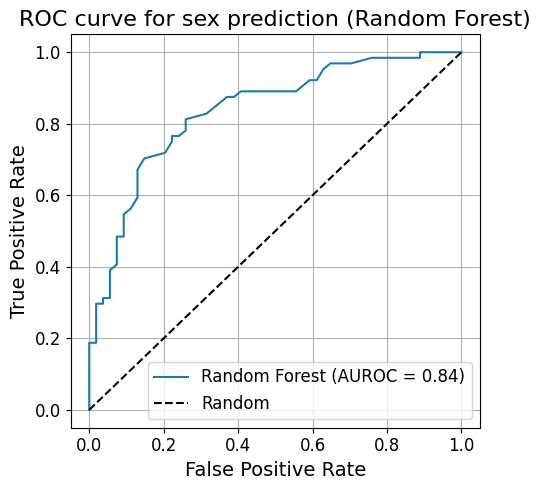

AUROC: 0.84


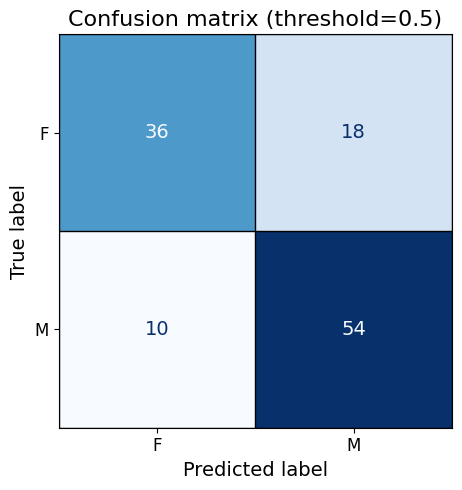


Classification report:

              precision    recall  f1-score   support

           F       0.78      0.67      0.72        54
           M       0.75      0.84      0.79        64

    accuracy                           0.76       118
   macro avg       0.77      0.76      0.76       118
weighted avg       0.76      0.76      0.76       118



In [82]:
rf_model, rf_metrics = run_random_forest_sex_model(input_mod, feature_cols=feature_cols)

In [83]:
# Cross-validated AUROC for the same RF pipeline
X_cv = input_mod[feature_cols].copy()
y_cv = input_mod["sex"].astype("category").cat.codes.values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipe_cv = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )),
    ]
)

cv_aurocs = cross_val_score(
    rf_pipe_cv,
    X_cv,
    y_cv,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

print("Cross-validated AUROC scores:", cv_aurocs)
print("Mean CV AUROC:", np.round(cv_aurocs.mean(), 3))
print("Std CV AUROC:", np.round(cv_aurocs.std(), 3))

Cross-validated AUROC scores: [0.92635659 0.84528424 0.88988095 0.84119601 0.84883721]
Mean CV AUROC: 0.87
Std CV AUROC: 0.033


In [84]:
def permutation_baseline_auroc(
    X: pd.DataFrame,
    y: np.ndarray,
    n_permutations: int = 100,
    test_size: float = 0.3,
    random_state: int = 42,
):
    """Compute permutation baseline AUROC by shuffling labels.

    Returns
    -------
    aurocs : np.ndarray
        AUROC values over permutations.
    """
    rng = np.random.RandomState(random_state)
    aurocs = []

    for i in range(n_permutations):
        # shuffle labels
        y_perm = y.copy()
        rng.shuffle(y_perm)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y_perm,
            test_size=test_size,
            stratify=y_perm,
            random_state=random_state + i,
        )

        pipe = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("rf", RandomForestClassifier(
                    n_estimators=200,
                    random_state=random_state + i,
                    n_jobs=-1,
                )),
            ]
        )

        pipe.fit(X_train, y_train)
        y_proba = pipe.predict_proba(X_test)[:, 1]
        auroc_perm = roc_auc_score(y_test, y_proba)
        aurocs.append(auroc_perm)

    return np.array(aurocs)

Permutation baseline AUROC (n=100)
Mean AUROC: 0.504
Std AUROC: 0.053
5th, 50th, 95th percentiles: [0.424 0.505 0.591]

Observed AUROC (original model): 0.836
Approximate permutation p-value: 0.0


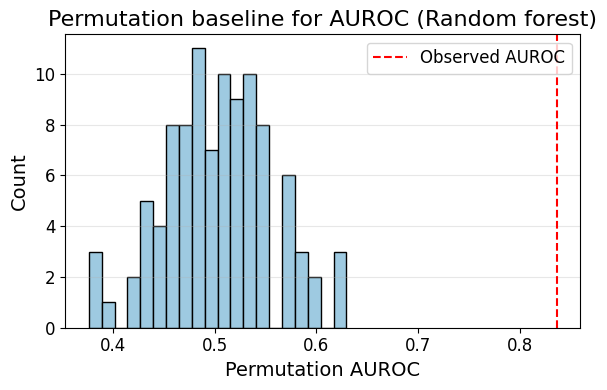

In [85]:
# Run permutation baseline analysis

X_perm = input_mod[feature_cols].copy()
y_perm = input_mod["sex"].astype("category").cat.codes.values

n_permutations = 100
perm_aurocs = permutation_baseline_auroc(
    X_perm,
    y_perm,
    n_permutations=n_permutations,
    test_size=0.3,
    random_state=42,
)

print(f"Permutation baseline AUROC (n={n_permutations})")
print("Mean AUROC:", np.round(perm_aurocs.mean(), 3))
print("Std AUROC:", np.round(perm_aurocs.std(), 3))
print(
    "5th, 50th, 95th percentiles:",
    np.round(np.percentile(perm_aurocs, [5, 50, 95]), 3),
)

# Compare to observed AUROC from held-out test
observed_auroc = rf_metrics["auroc"]
print("\nObserved AUROC (original model):", np.round(observed_auroc, 3))

# Simple p-value: fraction of permuted AUROCs >= observed
p_value = (perm_aurocs >= observed_auroc).mean()
print("Approximate permutation p-value:", np.round(p_value, 4))

# Optional: visualize null distribution
plt.figure(figsize=(6, 4))
plt.hist(perm_aurocs, bins=20, color="#9ecae1", alpha=1, edgecolor="black")
plt.axvline(observed_auroc, color="red", linestyle="--", label="Observed AUROC")
plt.xlabel("Permutation AUROC", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title("Permutation baseline for AUROC (Random forest)", fontsize=16)
ax_perm = plt.gca()
ax_perm.tick_params(axis="both", labelsize=12)
plt.legend(fontsize=12)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("output/random_forest/perm_rf_sex_auroc.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/random_forest/perm_rf_sex_auroc.png", dpi=300, bbox_inches="tight")
plt.show()

In [86]:
# Export cross-validated AUROCs to a DataFrame and CSV (Random Forest)

cv_df_rf = pd.DataFrame({
    "model": ["rf"] * len(cv_aurocs),
    "fold": np.arange(len(cv_aurocs)),
    "auroc": cv_aurocs,
})

cv_df_rf.to_csv("output/random_forest/cv_auroc_rf.csv", index=False)
cv_df_rf.head()

,model,fold,auroc
0,rf,0,0.926357
1,rf,1,0.845284
2,rf,2,0.889881
3,rf,3,0.841196
4,rf,4,0.848837


In [87]:
# Permutation-based negative control for RF (created from perm_aurocs)
cv_df_rf_perm = pd.DataFrame({
    "model": ["rf_perm"] * len(perm_aurocs),
    "fold": np.arange(len(perm_aurocs)),
    "auroc": perm_aurocs,
})
cv_df_rf_perm.to_csv("output/random_forest/cv_auroc_rf_perm.csv", index=False)



In [88]:
# Export permutation AUROCs as negative-control distribution ("rf_perm")

cv_df_rf_perm = pd.DataFrame({
    "model": ["rf_perm"] * len(perm_aurocs),
    "fold": np.arange(len(perm_aurocs)),
    "auroc": perm_aurocs,
})

cv_df_rf_perm.to_csv("output/cv_auroc_rf_perm.csv", index=False)
cv_df_rf_perm.head()

,model,fold,auroc
0,rf_perm,0,0.540799
1,rf_perm,1,0.463686
2,rf_perm,2,0.544126
3,rf_perm,3,0.462240
4,rf_perm,4,0.546007


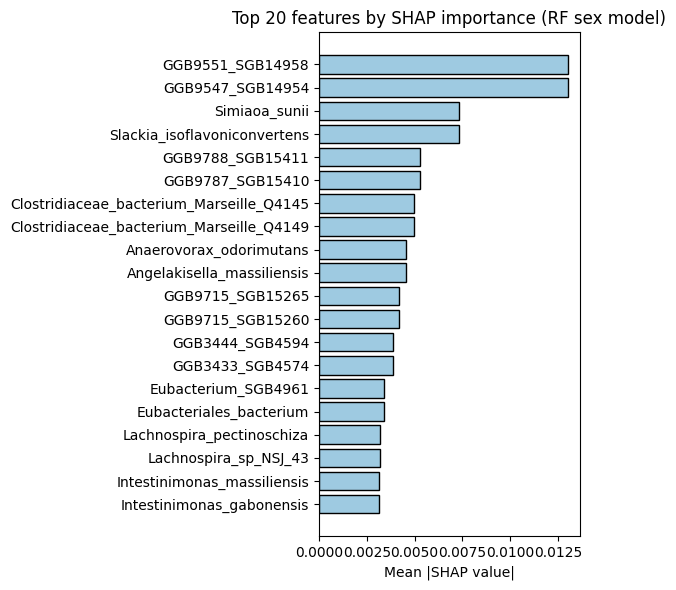

,feature,mean_abs_shap
341,GGB9551_SGB14958,0.012999
340,GGB9547_SGB14954,0.012999
542,Simiaoa_sunii,0.007315
543,Slackia_isoflavoniconvertens,0.007315
401,GGB9788_SGB15411,0.005278


In [89]:
# SHAP feature importance for Random Forest sex model

# If SHAP is not installed, install it first, e.g. in a terminal:
#   pip install shap

X_all = input_mod[feature_cols].copy()

# Use the trained pipeline and extract the underlying RF model
rf_pipe = rf_model
rf_estimator = rf_pipe.named_steps["rf"]

# Get scaled features used by the RF
X_scaled = rf_pipe.named_steps["scaler"].transform(X_all)

# Create TreeExplainer for the RF and compute SHAP values
explainer = shap.TreeExplainer(rf_estimator)
shap_values = explainer.shap_values(X_scaled)

# For binary classification, shap_values is a list [class0, class1]; use class 1
if isinstance(shap_values, list) and len(shap_values) > 1:
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# Bar plot: mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
mean_abs_shap = np.asarray(mean_abs_shap).ravel()

# Align feature names and importance lengths explicitly
n_feat = min(len(feature_cols), len(mean_abs_shap))
feat_names_aligned = np.array(feature_cols[:n_feat])
mean_abs_shap_aligned = mean_abs_shap[:n_feat]

shap_importance = pd.DataFrame({
    "feature": feat_names_aligned,
    "mean_abs_shap": mean_abs_shap_aligned,
}).sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(6, 6))
plt.barh(
    shap_importance["feature"].head(20)[::-1].values,
    shap_importance["mean_abs_shap"].head(20)[::-1].values,
    color="#9ecae1",
    edgecolor="black",
)
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 features by SHAP importance (RF sex model)")
plt.tight_layout()
plt.savefig("output/shap_rf_sex_bar_top20.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/shap_rf_sex_bar_top20.png", dpi=300, bbox_inches="tight")
plt.show()

shap_importance.head()

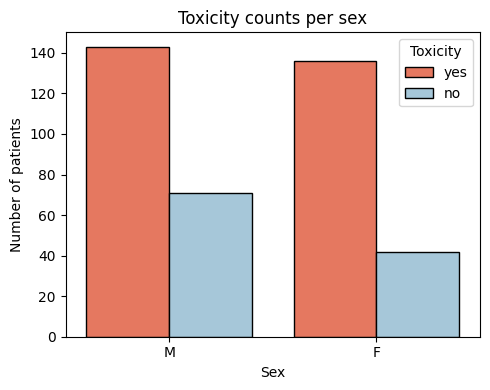

toxicity,no,yes
sex,,
F,42,136
M,71,143


In [90]:
tox_counts_df = (
    input[["sample", "sex", "toxicity"]]
    .drop_duplicates(subset=["sample"])
    .copy()
)

tox_counts_df = tox_counts_df[tox_counts_df["toxicity"].notna()].copy()
tox_counts_df["toxicity"] = tox_counts_df["toxicity"].astype(str).str.strip().str.lower()
tox_counts_df = tox_counts_df[tox_counts_df["toxicity"].isin(["yes", "no"])].copy()

plt.figure(figsize=(5, 4))
ax = sns.countplot(
    data=tox_counts_df,
    x="sex",
    hue="toxicity",
    order=["M", "F"],
    hue_order=["yes", "no"],
    edgecolor="black",
    palette={"yes": "#fb6a4a", "no": "#9ecae1"},
)

plt.xlabel("Sex")
plt.ylabel("Number of patients")
plt.title("Toxicity counts per sex")
plt.legend(title="Toxicity")
plt.tight_layout()
plt.savefig("output/random_forest/toxicity_counts_per_sex.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/random_forest/toxicity_counts_per_sex.png", dpi=300, bbox_inches="tight")
plt.show()

tox_counts_df.groupby(["sex", "toxicity"]).size().unstack(fill_value=0)

# Classification model for toxicity prediction / sex

__Male toxicity model__

In [91]:
tox_meta = (
    input[["sample", "sex", "toxicity"]]
    .drop_duplicates(subset=["sample"])
    .copy()
)

tox_meta = tox_meta[tox_meta["toxicity"].notna()].copy()
tox_meta["toxicity"] = tox_meta["toxicity"].astype(str).str.strip().str.lower()

input_tox = input.merge(
    tox_meta[["sample", "toxicity"]],
    on="sample",
    how="inner",
    suffixes=("", "_meta"),
)

input_tox_mod, tox_feature_cols = long_to_wide(
    df_long=input_tox,
    id_col="sample",
    feature_col="species",
    value_col="relative_abundance",
    sex_col="sex",
)

input_tox_mod = input_tox_mod.fillna(0.0)

In [92]:
tox_map = tox_meta.set_index("sample")["toxicity"]
input_tox_mod["toxicity"] = input_tox_mod["sample"].map(tox_map)

male_tox = input_tox_mod[input_tox_mod["sex"] == "M"].copy()
male_tox = male_tox[male_tox["toxicity"].isin(["yes", "no"])].copy()

X_male = male_tox[tox_feature_cols].copy()
y_male = (male_tox["toxicity"] == "yes").astype(int).values


In [93]:
def compute_cv_metrics_rf(
    X: pd.DataFrame,
    y: np.ndarray,
    sex_label: str,
    n_splits: int = 5,
    random_state: int = 42,
):
    """Compute CV metrics for RF toxicity model with threshold tuning.

    Returns a DataFrame with one row per fold and columns:
    sex, fold, threshold, auroc, balanced_accuracy, sensitivity, precision, f1.
    """
    cv_local = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv_local.split(X, y)):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("rf", RandomForestClassifier(
                    n_estimators=200,
                    random_state=random_state,
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                )),
            ]
        )

        # Threshold tuning using inner CV on train fold
        inner_cv = StratifiedKFold(
            n_splits=max(2, n_splits - 1), shuffle=True, random_state=random_state
        )
        y_train_oof_proba = cross_val_predict(
            pipe,
            X_train,
            y_train,
            cv=inner_cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

        thresholds = np.unique(np.round(y_train_oof_proba, 6))
        if thresholds.size == 0:
            tuned_threshold = 0.5
        else:
            best_bacc = -np.inf
            tuned_threshold = 0.5
            for thr in thresholds:
                y_train_oof_pred = (y_train_oof_proba >= thr).astype(int)
                bacc = balanced_accuracy_score(y_train, y_train_oof_pred)
                if bacc > best_bacc:
                    best_bacc = bacc
                    tuned_threshold = float(thr)

        pipe.fit(X_train, y_train)
        y_test_proba = pipe.predict_proba(X_test)[:, 1]
        y_test_pred = (y_test_proba >= tuned_threshold).astype(int)

        rows.append({
            "sex": sex_label,
            "fold": fold_idx,
            "threshold": tuned_threshold,
            "auroc": roc_auc_score(y_test, y_test_proba),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
            "sensitivity": recall_score(y_test, y_test_pred, zero_division=0),
            "precision": precision_score(y_test, y_test_pred, zero_division=0),
            "f1": f1_score(y_test, y_test_pred, zero_division=0),
        })

    return pd.DataFrame(rows)

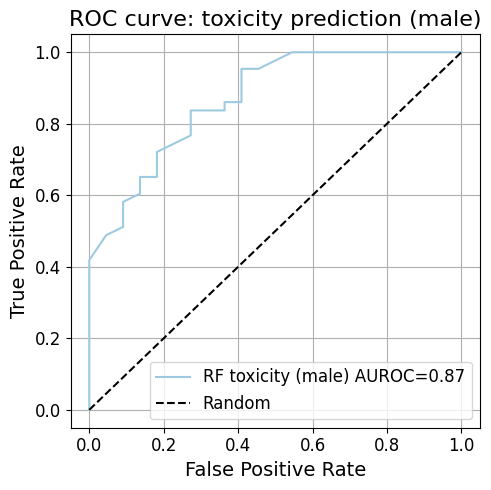

In [94]:
# Held-out ROC curve (male) + store predictions for later combined plot/metrics
X_train_male, X_test_male, y_train_male, y_test_male = train_test_split(
    X_male,
    y_male,
    test_size=0.3,
    stratify=y_male,
    random_state=42,
)

rf_pipe_tox_male = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1,
        )),
    ]
)

rf_pipe_tox_male.fit(X_train_male, y_train_male)
y_proba_male = rf_pipe_tox_male.predict_proba(X_test_male)[:, 1]
y_pred_male = (y_proba_male >= 0.5).astype(int)

fpr_male, tpr_male, _ = roc_curve(y_test_male, y_proba_male)
auroc_male = roc_auc_score(y_test_male, y_proba_male)

plt.figure(figsize=(5, 5))
plt.plot(fpr_male, tpr_male, color="#9ecae1", label=f"RF toxicity (male) AUROC={auroc_male:.2f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC curve: toxicity prediction (male)", fontsize=16)
ax_roc = plt.gca()
ax_roc.tick_params(axis="both", labelsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("output/random_forest/roc_rf_toxicity_male.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/random_forest/roc_rf_toxicity_male.png", dpi=300, bbox_inches="tight")
plt.show()

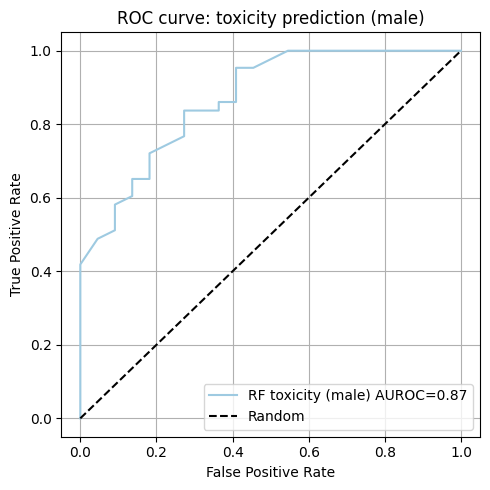

In [95]:
# Held-out ROC curve (male) + store predictions for later combined plot/metrics
X_train_male, X_test_male, y_train_male, y_test_male = train_test_split(
    X_male,
    y_male,
    test_size=0.3,
    stratify=y_male,
    random_state=42,
)

rf_pipe_tox_male = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1,
        )),
    ]
)

rf_pipe_tox_male.fit(X_train_male, y_train_male)
y_proba_male = rf_pipe_tox_male.predict_proba(X_test_male)[:, 1]
y_pred_male = (y_proba_male >= 0.5).astype(int)

fpr_male, tpr_male, _ = roc_curve(y_test_male, y_proba_male)
auroc_male = roc_auc_score(y_test_male, y_proba_male)

plt.figure(figsize=(5, 5))
plt.plot(fpr_male, tpr_male, color="#9ecae1", label=f"RF toxicity (male) AUROC={auroc_male:.2f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve: toxicity prediction (male)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("output/random_forest/roc_rf_toxicity_male.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/random_forest/roc_rf_toxicity_male.png", dpi=300, bbox_inches="tight")
plt.show()

__Female toxicity model__

Female toxicity model - CV AUROC scores: [0.92410714 0.94032922 0.79423868 0.94675926 0.88888889]
Female toxicity model - Mean CV AUROC: 0.899
Female toxicity model - Std CV AUROC: 0.056


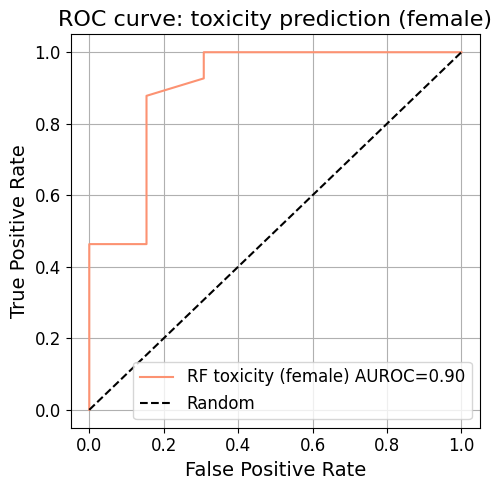

,sex,fold,threshold,auroc,balanced_accuracy,sensitivity,precision,f1
0,M,0,0.635,0.955665,0.894089,0.931034,0.931034,0.931034
1,M,1,0.630,0.874384,0.715517,0.931034,0.794118,0.857143
2,M,2,0.635,0.809113,0.754926,0.724138,0.875000,0.792453
3,M,3,0.725,0.890476,0.754762,0.642857,0.900000,0.750000
4,M,4,0.685,0.966837,0.839286,0.750000,0.954545,0.840000
5,F,0,0.760,0.924107,0.785714,0.821429,0.920000,0.867925
6,F,1,0.780,0.940329,0.796296,0.592593,1.000000,0.744186
7,F,2,0.725,0.794239,0.629630,0.814815,0.814815,0.814815
8,F,3,0.740,0.946759,0.819444,0.888889,0.923077,0.905660
9,F,4,0.780,0.888889,0.696759,0.518519,0.933333,0.666667


In [96]:
# Female toxicity model (F) + combined ROC plot (male vs female) + CV-based metrics table

# Build female subset and labels
female_tox = input_tox_mod[input_tox_mod["sex"] == "F"].copy()
female_tox = female_tox[female_tox["toxicity"].isin(["yes", "no"])].copy()

X_female = female_tox[tox_feature_cols].copy()
y_female = (female_tox["toxicity"] == "yes").astype(int).values

# CV AUROC (female)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipe_cv_tox_female = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1,
        )),
    ]
)

cv_aurocs_tox_female = cross_val_score(
    rf_pipe_cv_tox_female,
    X_female,
    y_female,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

print("Female toxicity model - CV AUROC scores:", cv_aurocs_tox_female)
print("Female toxicity model - Mean CV AUROC:", np.round(cv_aurocs_tox_female.mean(), 3))
print("Female toxicity model - Std CV AUROC:", np.round(cv_aurocs_tox_female.std(), 3))

cv_df_rf_tox_female = pd.DataFrame({
    "model": ["rf_tox_female"] * len(cv_aurocs_tox_female),
    "fold": np.arange(len(cv_aurocs_tox_female)),
    "auroc": cv_aurocs_tox_female,
})
cv_df_rf_tox_female.to_csv("output/random_forest/cv_auroc_rf_tox_female.csv", index=False)

# Held-out ROC curve (female) + store predictions for later combined plot/metrics
X_train_female, X_test_female, y_train_female, y_test_female = train_test_split(
    X_female,
    y_female,
    test_size=0.3,
    stratify=y_female,
    random_state=42,
)

rf_pipe_tox_female = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1,
        )),
    ]
)

rf_pipe_tox_female.fit(X_train_female, y_train_female)
y_proba_female = rf_pipe_tox_female.predict_proba(X_test_female)[:, 1]
y_pred_female = (y_proba_female >= 0.5).astype(int)

fpr_female, tpr_female, _ = roc_curve(y_test_female, y_proba_female)
auroc_female = roc_auc_score(y_test_female, y_proba_female)

plt.figure(figsize=(5, 5))
plt.plot(fpr_female, tpr_female, color="#fc9272", label=f"RF toxicity (female) AUROC={auroc_female:.2f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC curve: toxicity prediction (female)", fontsize=16)
ax_roc = plt.gca()
ax_roc.tick_params(axis="both", labelsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("output/random_forest/roc_rf_toxicity_female.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/random_forest/roc_rf_toxicity_female.png", dpi=300, bbox_inches="tight")
plt.show()

# CV-based metrics (per fold) for BOTH male and female
cv_metrics_male = compute_cv_metrics_rf(X_male, y_male, sex_label="M", n_splits=5, random_state=42)
cv_metrics_female = compute_cv_metrics_rf(X_female, y_female, sex_label="F", n_splits=5, random_state=42)

cv_metrics_df = pd.concat([cv_metrics_male, cv_metrics_female], ignore_index=True)
cv_metrics_df.to_csv("output/random_forest/metrics_cv_rf_toxicity_male_female.csv", index=False)

# Summary (mean/std across folds)
cv_metrics_summary = (
    cv_metrics_df
    .groupby("sex")[['auroc', 'balanced_accuracy', 'sensitivity', 'precision', 'f1']]
    .agg(["mean", "std"])
)

cv_metrics_summary.to_csv("output/random_forest/metrics_cv_summary_rf_toxicity_male_female.csv")

cv_metrics_df

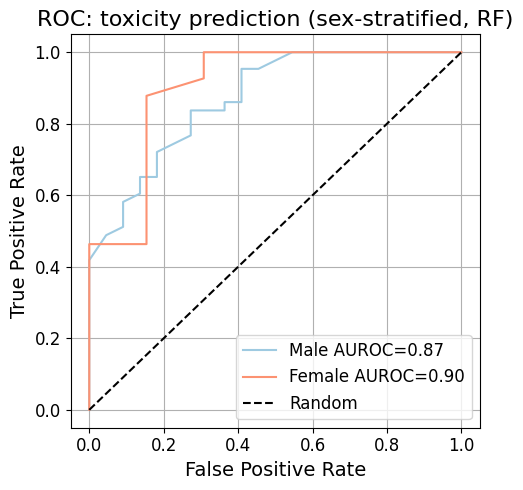

,sex,auroc,sensitivity,precision,f1
0,M,0.869450,1.0,0.716667,0.834951
1,F,0.902439,1.0,0.773585,0.872340


In [97]:
# Combined ROC plot
plt.figure(figsize=(5, 5))
plt.plot(fpr_male, tpr_male, color="#9ecae1", label=f"Male AUROC={auroc_male:.2f}")
plt.plot(fpr_female, tpr_female, color="#fc9272", label=f"Female AUROC={auroc_female:.2f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC: toxicity prediction (sex-stratified, RF)", fontsize=16)
ax_roc = plt.gca()
ax_roc.tick_params(axis="both", labelsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("output/random_forest/roc_rf_toxicity_male_vs_female.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/random_forest/roc_rf_toxicity_male_vs_female.png", dpi=300, bbox_inches="tight")
plt.show()

# Metrics DataFrame (held-out, threshold=0.5)
metrics_df = pd.DataFrame([
    {
        "sex": "M",
        "auroc": auroc_male,
        "sensitivity": recall_score(y_test_male, y_pred_male, zero_division=0),
        "precision": precision_score(y_test_male, y_pred_male, zero_division=0),
        "f1": f1_score(y_test_male, y_pred_male, zero_division=0),
    },
    {
        "sex": "F",
        "auroc": auroc_female,
        "sensitivity": recall_score(y_test_female, y_pred_female, zero_division=0),
        "precision": precision_score(y_test_female, y_pred_female, zero_division=0),
        "f1": f1_score(y_test_female, y_pred_female, zero_division=0),
    },
])

metrics_df.to_csv("output/random_forest/metrics_rf_toxicity_male_female.csv", index=False)
metrics_df

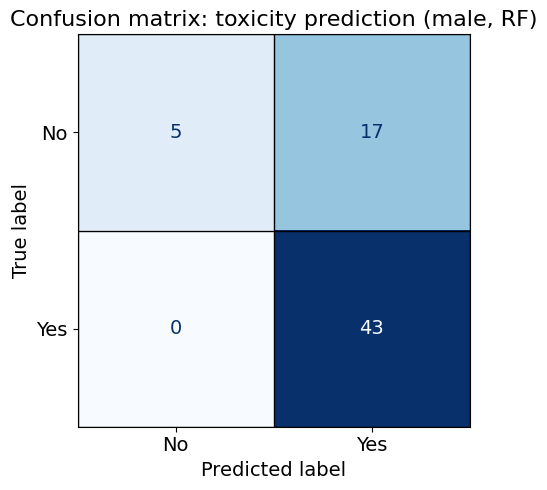

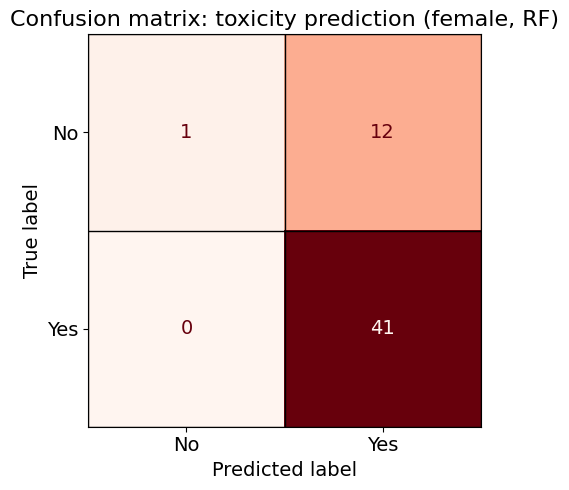

In [98]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

os.makedirs("output/random_forest", exist_ok=True)

# Male confusion matrix (toxicity)
cm_male = confusion_matrix(y_test_male, y_pred_male)
disp_male = ConfusionMatrixDisplay(confusion_matrix=cm_male, display_labels=["No", "Yes"])
fig, ax = plt.subplots(figsize=(5.5, 5))
ax_male = disp_male.plot(cmap="Blues", values_format="d", colorbar=False, ax=ax).ax_
ax_male.set_xticks(np.arange(cm_male.shape[1] + 1) - 0.5, minor=True)
ax_male.set_yticks(np.arange(cm_male.shape[0] + 1) - 0.5, minor=True)
ax_male.grid(which="minor", color="black", linestyle="-", linewidth=1)
ax_male.tick_params(which="minor", bottom=False, left=False)
ax_male.set_xlabel("Predicted label", fontsize=14)
ax_male.set_ylabel("True label", fontsize=14)
ax_male.tick_params(axis="both", labelsize=14)
for t in ax_male.texts:
    t.set_fontsize(14)
plt.title("Confusion matrix: toxicity prediction (male, RF)", fontsize=16)
plt.tight_layout()
plt.savefig("output/random_forest/cm_rf_toxicity_male.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/random_forest/cm_rf_toxicity_male.png", dpi=300, bbox_inches="tight")
plt.show()

# Female confusion matrix (toxicity)
cm_female = confusion_matrix(y_test_female, y_pred_female)
disp_female = ConfusionMatrixDisplay(confusion_matrix=cm_female, display_labels=["No", "Yes"])
fig, ax = plt.subplots(figsize=(5.5, 5))
ax_female = disp_female.plot(cmap="Reds", values_format="d", colorbar=False, ax=ax).ax_
ax_female.set_xticks(np.arange(cm_female.shape[1] + 1) - 0.5, minor=True)
ax_female.set_yticks(np.arange(cm_female.shape[0] + 1) - 0.5, minor=True)
ax_female.grid(which="minor", color="black", linestyle="-", linewidth=1)
ax_female.tick_params(which="minor", bottom=False, left=False)
ax_female.set_xlabel("Predicted label", fontsize=14)
ax_female.set_ylabel("True label", fontsize=14)
ax_female.tick_params(axis="both", labelsize=14)
for t in ax_female.texts:
    t.set_fontsize(14)
plt.title("Confusion matrix: toxicity prediction (female, RF)", fontsize=16)
plt.tight_layout()
plt.savefig("output/random_forest/cm_rf_toxicity_female.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/random_forest/cm_rf_toxicity_female.png", dpi=300, bbox_inches="tight")
plt.show()

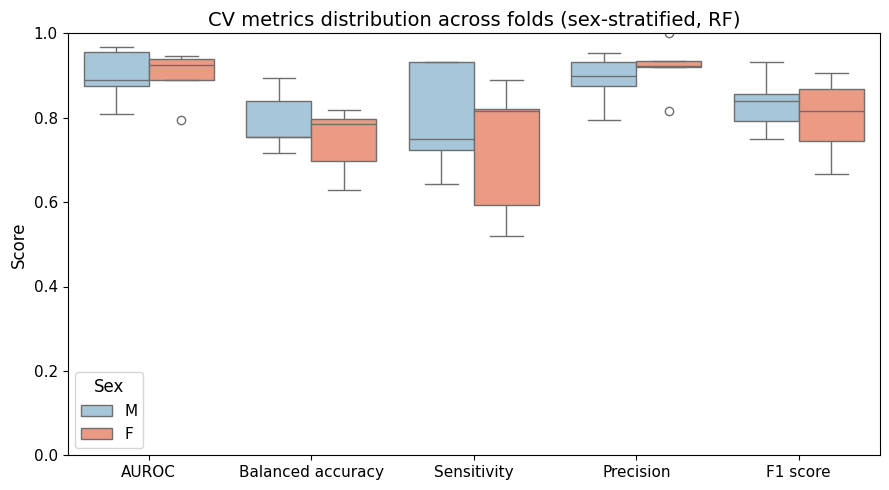

In [99]:
metric_cols = [
    "auroc",
    "balanced_accuracy",
    "sensitivity",
    "precision",
    "f1",
]

label_map = {
    "auroc": "AUROC",
    "balanced_accuracy": "Balanced accuracy",
    "sensitivity": "Sensitivity",
    "precision": "Precision",
    "f1": "F1 score",
}

plot_df = cv_metrics_df[["sex", *metric_cols]].melt(
    id_vars="sex",
    value_vars=metric_cols,
    var_name="metric",
    value_name="value",
)
plot_df["metric"] = plot_df["metric"].map(label_map)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=plot_df,
    x="metric",
    y="value",
    hue="sex",
    order=[label_map[m] for m in metric_cols],
    palette={"M": "#9ecae1", "F": "#fc9272"},
)

ax.set_title("CV metrics distribution across folds (sex-stratified, RF)", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=12)
ax.tick_params(axis="x", labelsize=11, rotation=0)
ax.tick_params(axis="y", labelsize=11)

leg = ax.legend(title="Sex", fontsize=11, title_fontsize=12, loc="best")

plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("output/random_forest/boxplot_cv_metrics_rf_toxicity_male_female.pdf", dpi=300, bbox_inches="tight")
plt.savefig("output/random_forest/boxplot_cv_metrics_rf_toxicity_male_female.png", dpi=300, bbox_inches="tight")
plt.show()

In [100]:
import os
import joblib

os.makedirs("models", exist_ok=True)

model_bundle = {
    "model": rf_model,
    "feature_cols": feature_cols,
    "threshold": 0.5,
}

joblib.dump(model_bundle, "models/rf_sex.joblib")


['models/rf_sex.joblib']